In [ ]:
N=11
k=6
nf = Newforms(N, k, names='a')
for index in range(0,len(nf)):
    print("index:",index)
    f = nf[index]
    K = f.base_ring()
    print("K:",K)


In [25]:
from sage.all import *
from sage.all import *
import pickle
import time


def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return (tr,d)

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    dim_S=S.dimension()
    print("dimension of S:",dim_S)
    print()
    NF = S.newforms(names='a')
    dim_NF=S.new_subspace().dimension()
    print("dimension of NF:",dim_NF)
    print()
    results = []

    for f in NF:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            
        if K !=QQ:
            tr = trace_functional(K)[0]
       
            coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
            results.append(coeffs)

    return (results)

start=time.time()

N=11
k=6
        
precision=500 # need a long list to find 350 primes
gos=galois_orbit_sum(N, k, precision)
print("len(gos):",len(gos))
print()
for j in range(0,len(gos)):
    print("orbit",j)
    orbit=gos[j]
    indexed_list=[(n,orbit[n]) for n in range(1,500)]
    print(indexed_list[:20])
    print()

dimension of S: 4

dimension of NF: 4

len(gos): 2

orbit 0
[(1, 1), (2, -4), (3, -15), (4, -16), (5, -19), (6, 60), (7, 10), (8, 192), (9, -18), (10, 76), (11, -121), (12, 240), (13, -1148), (14, -40), (15, 285), (16, -256), (17, 686), (18, 72), (19, -384), (20, 304)]

orbit 1
[(1, 3), (2, 0), (3, 34), (4, 84), (5, 24), (6, -206), (7, 84), (8, -564), (9, -7), (10, -414), (11, 363), (12, 992), (13, 486), (14, -1020), (15, 1654), (16, 1992), (17, 1086), (18, -3706), (19, 1380), (20, -3480)]



In [1]:
from sage.all import *
import pickle

from sage.all import *
import pickle
import time


def trace_functional(K):
    """
    Returns a fast trace evaluator on K using its power basis.
    """
    d = K.degree()
    a = K.gen()

    # Precompute traces of basis elements
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        # pad to full length
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return (tr,d)

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    dim_S=S.dimension()
    print("dimension of S:",dim_S)
    print()
    NF = S.newforms(names='a')
    dim_NF=S.new_subspace().dimension()
    print("dimension of NF:",dim_NF)
    print()
    results = []

    for f in NF:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            
        if K !=QQ:
            tr = trace_functional(K)[0]
       
            coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
            results.append(coeffs)

    return (results)
    
N=11
k=6
precision=400
gos=galois_orbit_sum(N, k, precision)
print("number of Galois orbits:",len(gos))
print()
print(gos[0][0:20])
print()
short=gos[0][1:20]
print(short)
print()
indexed_list=[(n,gos[0][n]) for n in range(0,len(gos[0]))]
print(indexed_list[:20])
print()
prime_list=[pair[1] for pair in indexed_list if is_prime(-1+pair[0])]
print(prime_list[:20])

dimension of S: 4

dimension of NF: 4

number of Galois orbits: 2

[0, 1, -4, -15, -16, -19, 60, 10, 192, -18, 76, -121, 240, -1148, -40, 285, -256, 686, 72, -384]

[1, -4, -15, -16, -19, 60, 10, 192, -18, 76, -121, 240, -1148, -40, 285, -256, 686, 72, -384]

[(0, 0), (1, 1), (2, -4), (3, -15), (4, -16), (5, -19), (6, 60), (7, 10), (8, 192), (9, -18), (10, 76), (11, -121), (12, 240), (13, -1148), (14, -40), (15, 285), (16, -256), (17, 686), (18, 72), (19, -384)]

[-15, -16, 60, 192, 240, -40, 72, 304, -2880, -1140, -5120, 1536, 600, 1936, 3840, -15660, -4560, 25772, -10976, -3456]



orbit_0[:20]
[0, 1, -4, -15, -16, -19, 60, 10, 192, -18, 76, -121, 240, -1148, -40, 285, -256, 686, 72, -384]

[(0, 0), (1, 1), (2, -4), (3, -15), (4, -16), (5, -19), (6, 60), (7, 10), (8, 192), (9, -18), (10, 76), (11, -121), (12, 240), (13, -1148), (14, -40), (15, 285), (16, -256), (17, 686), (18, 72), (19, -384)]

primes_plus1_list[:20]
[-15, -16, 60, 192, 240, -40, 72, 304, -2880, -1140, -5120, 1536, 600, 1936, 3840, -15660, -4560, 25772, -10976, -3456]

h_list[:20]
[1, -15, -16, 60, 192, 240, -40, 72, 304, -2880, -1140, -5120, 1536, 600, 1936, 3840, -15660, -4560, 25772, -10976]

('j_list', 100)
('j_list', 200)
('j_list', 300)
('j_list', 400)
1 1.2949431498845418
2 1.295634400844574
3 1.2956604838371277
4 1.296039585272471
5 1.2960705041885376
6 1.2960939168930055
7 1.296126651763916
8 1.296191151936849
9 1.296238120396932
10 1.296304968992869
11 1.2963840325673421
12 1.296465035279592
13 1.2965545336405435
14 1.2966865698496501
15 1.2968084692955018
16 1.2969397226969401
17 1.29

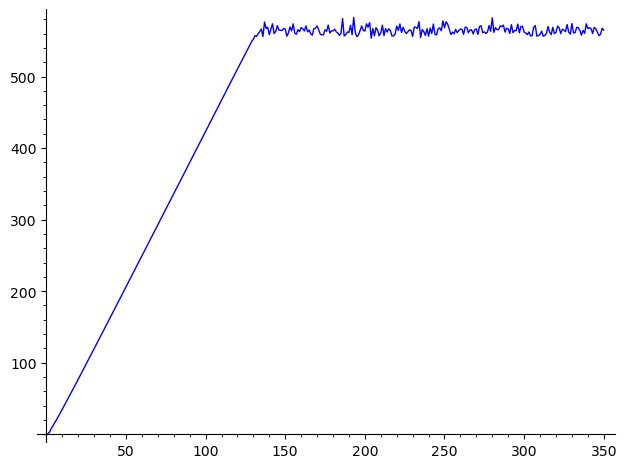

In [2]:
from sage.all import *
import pickle
import time

start=time.time()
def trace_functional(K):
    d = K.degree()
    a = K.gen()
    basis = [a^i for i in range(d)]
    trace_vals = [b.trace() for b in basis]

    def tr(x):
        coeffs = x.polynomial().coefficients(sparse=False)
        coeffs += [0]*(d - len(coeffs))
        return sum(coeffs[i]*trace_vals[i] for i in range(d))

    return (tr,d)

def galois_orbit_sum(N, k, precision):
    S = CuspForms(N, k)
    dim_S=S.dimension()
    NF = S.newforms(names='a')
    dim_NF=S.new_subspace().dimension()
    print()
    results = []

    for f in NF:
        K = f.base_ring()
        qexp = f.q_expansion(precision)

        if K == QQ:
            results.append([QQ(qexp[n]) for n in range(precision)])
            
        if K !=QQ:
            tr = trace_functional(K)[0]
       
            coeffs = [QQ(tr(qexp[n])) for n in range(precision)]
            results.append(coeffs)

    return (results)
    
N=11
k=6
precision=2800 
gos=galois_orbit_sum(N, k, precision)
orbit_0=gos[0]
print("orbit_0[:20]")
print(orbit_0[:20])
print()
indexed_list=[(n,orbit_0[n]) for n in range(0,len(orbit_0))]
print(indexed_list[:20])
print()
primes_plus1_list=[pair[1] for pair in indexed_list if is_prime(-1+pair[0])]
print("primes_plus1_list[:20]")
print(primes_plus1_list[:20])
print()
h_list=[1]+primes_plus1_list
print("h_list[:20]")
print(h_list[:20])
print()
j_list=[(0,1)] #<<<<<<<<<< c = 1
for n in range(1,401):
    sm=0
    for r in range(1,n):
        sm=sm+j_list[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    j_list.append((n,j_n))
    if n%100==0:
        print(("j_list",n))

with open('/Users/barrybrent/data2/run14april26no11.txt', 'wb') as wfile:
    pickle.dump(gos[0], wfile)   
with open('/Users/barrybrent/data2/run14april26no12.txt', 'wb') as wfile:
    pickle.dump(j_list, wfile) 

    
def P_matrix(lst):
    lenlist=len(lst)
    columns=[lst]
    for k in range(1,lenlist):
        column=[0]*(k-1)
        column=column+[-k]
        column=flatten(column+[lst])
        column=column+[lst]
        column=column[:lenlist]
        columns+=[column]
    return (matrix(columns)).transpose()

from sage.all import *
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)  # Can remain in preamble if all polynomials are in one variable

charpol_list=[]
roots_list=[]

mins_list=[]
log_mins_list=[]

dets=[]

for n in range(1, 351):
    now=time.time()
    print(n,(now-start)/60)
    deformed_j_list=j_list[:n]
    inputs=[pair[1] for pair in deformed_j_list]
    pl=P_matrix(inputs) 
    det=pl.det()
    dets.append((n,det))
    cp=pl.charpoly()
    charpol_list.append((n,cp))
    roots = cp.roots(ring=CC, multiplicities=False)       
    roots_list.append((n,roots))
    aar = [r.abs() for r in roots]
    if aar!=[]:
        minn = min(aar)  
        mins_list.append((n,minn))
        


p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()



with open('/Users/barrybrent/data2/run14april26no13.txt', 'wb') as wfile:
    pickle.dump(roots_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run14april26no14.txt', 'wb') as wfile:
    pickle.dump(charpol_list, wfile) #output snipped

with open('/Users/barrybrent/data2/run14april26no15.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile) #output snipped